# Exploring MCU end-of-line test data

This notebook walks through the same steps as the pipeline, one at a time, and asks one question at the end: **is the rise in hot leakage on station T3 a data problem or a process problem?**

All data is synthetic (see `src/mcu_analytics/generate.py`).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mcu_analytics.generate import generate, START, SPEC
from mcu_analytics.validate import validate, clean
from mcu_analytics.kpis import load, read_kpis, headline
from mcu_analytics.spc import control_chart, first_alarm, capability_table

pd.set_option('display.width', 140)
data = generate(seed=7)
as_of = START + pd.Timedelta(days=data.days + 1)
print(f'{len(data.tests):,} test rows, {data.tests.unit_id.nunique():,} units, {len(data.lots)} lots')
data.tests.head()

37,261 test rows, 12,000 units, 40 lots


,test_id,unit_id,lot_id,wafer_id,temperature_c,station_id,test_ts,supply_current_ma,leakage_ua,max_clock_mhz,vdd_v,bin_code,result
0,T0032386,L016-W01-U043,L016,L016-W01,125,T1,2026-08-26 01:25:39.978745276,25.6386,1.1406,314.9682,3.2995,1,PASS
1,T0033077,L031-W05-U050,L031,L031-W05,25,T4,2026-08-26 13:07:44.743510883,29.0715,0.6315,340.9580,3.3254,1,PASS
2,T0012731,L021-W05-U053,L021,L021-W05,25,T2,2026-08-09 14:02:16.808942090,30.5572,0.2704,317.5015,3.3045,1,PASS
3,T0028717,L015-W01-U003,L015,L015-W01,-40,T3,2026-08-24 08:18:38.689885303,24.1168,0.1339,353.5187,3.3051,1,PASS
4,T0013088,L023-W02-U008,L023,L023-W02,25,T4,2026-08-11 04:19:26.758524316,22.7329,0.3747,319.8320,3.3011,1,PASS


## 1. First look at the raw data

Summary statistics already hint at problems: look at the maximum leakage and the temperature values.

In [2]:
data.tests.describe().T[['count', 'mean', 'min', '50%', 'max']].round(3)

,count,mean,min,50%,max
temperature_c,37261.0,38.642951,-40.0,25.0,250.0
test_ts,37261,2026-08-16 02:00:59.064013824,2026-08-01 00:00:21.917279260,2026-08-15 00:32:36.874796032,2031-08-25 21:03:24.999486264
supply_current_ma,37192.0,25.878107,14.5633,25.8754,37.283
leakage_ua,37196.0,7.361768,0.0132,0.4219,6457.0
max_clock_mhz,37215.0,328.684822,282.542,328.8724,373.5196
vdd_v,37261.0,3.30001,3.2622,3.3,3.3376
bin_code,37261.0,1.071254,1.0,1.0,4.0


In [3]:
data.tests['temperature_c'].value_counts().sort_index()

temperature_c
-40     12160
 25     12151
 125    12920
 250       30
Name: count, dtype: int64

## 2. Data quality rules

Each rule flags rows and gives a likely cause, so the owner of the source system knows what to fix.

In [4]:
quality = validate(data.tests, data.lots, as_of)
quality[['rule_id', 'rule', 'action', 'rows_flagged', 'likely_cause']]

,rule_id,rule,action,rows_flagged,likely_cause
0,R01,duplicate_test_id,drop,280,File loaded twice or tester re-sent a record
1,R02,missing_measurement,quarantine,180,Tester aborted or the value was not logged
2,R03,implausible_leakage,quarantine,225,Value logged in nA instead of uA
3,R04,invalid_temperature,quarantine,30,Chamber sensor glitch or wrong test program
4,R05,future_timestamp,quarantine,20,Tester clock set wrong
5,R06,bin_result_mismatch,quarantine,25,Binning table out of sync with the test program
6,R07,unknown_lot,quarantine,15,Typo at lot start or missing master data entry


The leakage values flagged by R03 all come from one station on one day, and they are about 1000 times too high. That pattern points to a unit change (nA instead of uA), not to bad parts.

In [5]:
c, quarantine, dropped = clean(data.tests, data.lots, as_of)
r03 = quarantine[quarantine.reasons.str.contains('implausible_leakage')]
print(r03.groupby(['station_id', r03.test_ts.dt.date]).size())
print('median flagged leakage:', round(r03.leakage_ua.median(), 1))
print(f'clean rows: {len(c):,} | quarantined: {len(quarantine)} | duplicates dropped: {dropped}')

station_id  test_ts   
T2          2026-08-11    225
dtype: int64
median flagged leakage: 459.3
clean rows: 36,486 | quarantined: 495 | duplicates dropped: 280


## 3. Distributions at each temperature

Leakage grows strongly with temperature and is right-skewed, which is why the control chart later uses log values.

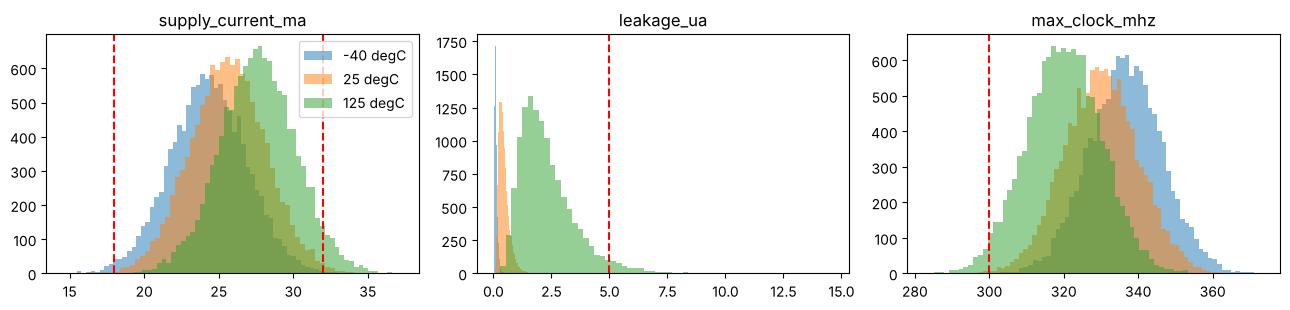

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (param, lim) in zip(axes, SPEC.items()):
    for t, g in c.groupby('temperature_c'):
        ax.hist(g[param].dropna(), bins=60, alpha=0.5, label=f'{t} degC')
    for v in (lim['lsl'], lim['usl']):
        if v is not None:
            ax.axvline(v, color='red', linestyle='--')
    ax.set_title(param)
axes[0].legend()
plt.tight_layout()

## 4. Yield KPIs from SQL

The KPI logic lives in `sql/kpis.sql` (window functions for retest attempts and rolling averages).

In [7]:
con = load(c, data.lots)
kpis = read_kpis(con)
print(headline(con))
kpis['v_yield_by_temperature']

{'units': 12000, 'first_pass_yield_pct': 88.42, 'final_yield_pct': 95.43}


,temperature_c,insertions,first_pass_yield_pct,final_yield_pct
0,-40,11839,99.10,99.74
1,25,11856,99.16,99.67
2,125,11832,89.79,95.92


In [8]:
kpis['v_bin_pareto']

,bin_code,bin_name,fails,share_pct,cumulative_pct
0,2,Supply current out of spec,746,49.34,49.34
1,3,Leakage too high,483,31.94,81.28
2,4,Clock below spec,283,18.72,100.00


## 5. Is the T3 leakage rise a data problem or a process problem?

In [9]:
first = pd.read_sql_query('SELECT * FROM v_attempts WHERE attempt = 1', con)
chart = control_chart(first[first.temperature_c == 125])
first_alarm(chart)

,station_id,test_day,rule1,rule2
0,T3,2026-08-23,True,False
1,T4,2026-08-27,True,False


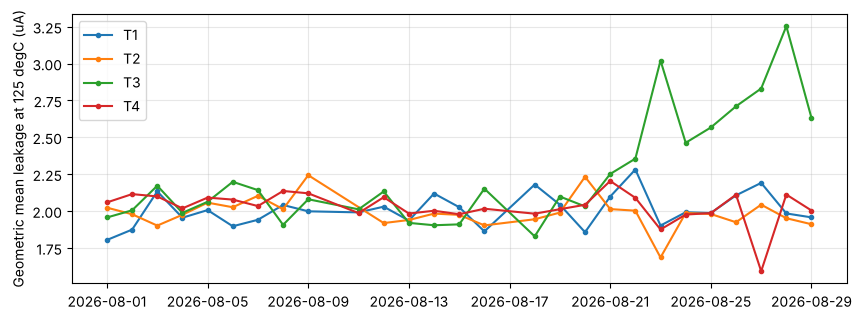

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for st, g in chart.groupby('station_id'):
    ax.plot(pd.to_datetime(g.test_day), g.geo_mean_ua, marker='.', label=st)
ax.set_ylabel('Geometric mean leakage at 125 degC (uA)')
ax.legend()
ax.grid(alpha=0.3)

In [11]:
hot = first[first.temperature_c == 125].copy()
hot['period'] = np.where(pd.to_datetime(hot.test_day) >= START + pd.Timedelta(days=18), 'from day 18', 'before')
hot.pivot_table(index='station_id', columns='period', values='leakage_ua', aggfunc='median').round(2)

period,before,from day 18
station_id,,
T1,2.00,2.03
T2,2.00,1.97
T3,1.99,2.54
T4,2.05,2.00


**Reading the evidence**

- The T3 rows passed every data quality rule: no missing values, plausible units, valid temperatures.
- The rise is gradual and continues day after day, unlike the one-day jump of the unit error.
- It appears on one station only, while the same products tested on other stations stay flat.

That points to the test station or its setup (for example a drifting temperature chamber), so the next step would be to check T3's hardware and calibration, not the data feed.

One caveat from the chart: a stable station can still raise a single-day alarm by chance. Running `scripts/evaluate_spc.py` over 20 simulated months measures how often that happens.

## 6. Process capability

In [12]:
capability_table(first).query('cpk < 1.33')

,parameter,temperature_c,n,mean,std,lsl,usl,cpk
0,supply_current_ma,-40,11839,24.293,2.563,18.0,32.0,0.82
1,supply_current_ma,25,11856,25.605,2.554,18.0,32.0,0.83
2,supply_current_ma,125,11832,27.621,2.555,18.0,32.0,0.57
5,leakage_ua,125,11832,2.334,1.268,NaN,5.0,0.70
6,max_clock_mhz,-40,11839,336.587,9.893,300.0,NaN,1.23
7,max_clock_mhz,25,11856,330.015,9.929,300.0,NaN,1.01
8,max_clock_mhz,125,11832,320.036,10.086,300.0,NaN,0.66


1.33 is a common minimum for a capable process. Supply current at 125 degC has the lowest Cpk, which matches it being the largest fail bin in the Pareto: improving its centering would recover more yield than any other single change.